In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn pandas pillow

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

#Task 1: Data Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir("/content/drive/MyDrive")

['Untitled document.gdoc',
 'Striver_A2Z_Full_Skeleton.gsheet',
 'Untitled spreadsheet.gsheet',
 'data.csv',
 'sampled_images-20260313T105444Z-1-001.zip',
 'Colab Notebooks']

In [ ]:
!unzip "/content/drive/MyDrive/sampled_images-20260313T105444Z-1-001.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/sampled_images/TN_Good_2023-02-21-08.30-1-116.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-22-09.30-1-131.jpg  
  inflating: /content/sampled_images/MH_VUN_2023-03-05-08.30-2-66.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-20-16.30-2-26.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-21-08.30-2-126.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-20-16.30-1-116.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-21-08.30-3-196.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-20-16.30-1-71.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-20-16.30-2-21.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-20-16.30-1-101.jpg  
  inflating: /content/sampled_images/MH_VUN_2023-03-05-08.30-2-51.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-20-08.30-1-48.jpg  
  inflating: /content/sampled_images/TN_Good_2023-02-21-08.30-3-1.jpg

In [ ]:
import os

os.listdir("/content/")

['.config', 'drive', 'sampled_images', 'sample_data']

In [ ]:
os.listdir("/content/sampled_images")[:10]

['DEL_UnH_2023-02-15-11.30-2-23.jpg',
 'DEL_SEV_2023-02-20-14.00-2-596.jpg',
 'MH_UnFSG_2023-02-15-10.30-1-72.jpg',
 'BIR_UNH_VF_2023-02-02- 12.00-1-97.jpg',
 'TN_Good_2023-02-22-09.30-1-171.jpg',
 'DEL_SEV_2023-02-22-14.00-1-186.jpg',
 'UP_VUN_2023-03-02-09.00-1-269.jpg',
 'TN_Good_2023-02-22-09.30-3-191.jpg',
 'DEL_SEV_2023-02-20-14.00-2-446.jpg',
 'TN_Good_2023-02-23-08.30-2-141.jpg']

In [ ]:
csv_path = "/content/drive/MyDrive/data.csv"

df = pd.read_csv(csv_path)

df = df[['Filename','AQI_Class']]

df = df.rename(columns={'Filename':'image_path'})

df.head()

,image_path,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good


In [ ]:
class_names = df['AQI_Class'].unique()

class_to_idx = {cls:i for i,cls in enumerate(class_names)}

df['label'] = df['AQI_Class'].map(class_to_idx)

df.head()

,image_path,AQI_Class,label
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good,0
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good,0
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good,0
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good,0
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good,0


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

4200 900 900


In [33]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [34]:
class AQIDataset(Dataset):

    def __init__(self, dataframe, img_folder, transform=None):
        self.data = dataframe
        self.img_folder = img_folder
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.img_folder,
            self.data.iloc[idx]['image_path']
        )

        image = Image.open(img_path).convert("RGB")

        label = self.data.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
image_folder = "/content/sampled_images"

train_dataset = AQIDataset(train_df, image_folder, transform)
val_dataset = AQIDataset(val_df, image_folder, transform)
test_dataset = AQIDataset(test_df, image_folder, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


# Task 2: Basic CNN Model

In [53]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super(SimpleCNN,self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),
            nn.Linear(64*28*28,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x

In [54]:
model = SimpleCNN(len(class_names)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [55]:
def train_model(model, train_loader, val_loader, epochs):

    train_loss_list=[]
    val_loss_list=[]
    train_acc_list=[]
    val_acc_list=[]

    for epoch in range(epochs):

        model.train()

        running_loss=0
        correct=0
        total=0

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss+=loss.item()

            _,pred=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(pred==labels).sum().item()

        train_loss=running_loss/len(train_loader)
        train_acc=correct/total

        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)

        # VALIDATION
        model.eval()

        val_loss=0
        val_correct=0
        val_total=0

        with torch.no_grad():

            for images,labels in val_loader:

                images=images.to(device)
                labels=labels.to(device)

                outputs=model(images)

                loss=criterion(outputs,labels)

                val_loss+=loss.item()

                _,pred=torch.max(outputs,1)

                val_total+=labels.size(0)
                val_correct+=(pred==labels).sum().item()

        val_loss=val_loss/len(val_loader)
        val_acc=val_correct/val_total

        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        print("Epoch",epoch+1,
              "Train Loss:",train_loss,
              "Train Acc:",train_acc,
              "Val Loss:",val_loss,
              "Val Acc:",val_acc)

    return train_loss_list,val_loss_list,train_acc_list,val_acc_list

In [56]:
train_loss,val_loss,train_acc,val_acc = train_model(model,train_loader,val_loader,5)

Epoch 1 Train Loss: 1.1887263511166428 Train Acc: 0.5283333333333333 Val Loss: 0.9171220413569746 Val Acc: 0.6666666666666666
Epoch 2 Train Loss: 0.5986598295470079 Train Acc: 0.7871428571428571 Val Loss: 0.6399280305566459 Val Acc: 0.7644444444444445
Epoch 3 Train Loss: 0.32546458156271413 Train Acc: 0.8811904761904762 Val Loss: 0.43691009128915853 Val Acc: 0.8544444444444445
Epoch 4 Train Loss: 0.19716916919093241 Train Acc: 0.9297619047619048 Val Loss: 0.40490726869681787 Val Acc: 0.86
Epoch 5 Train Loss: 0.09865200150913249 Train Acc: 0.969047619047619 Val Loss: 0.4959728738357281 Val Acc: 0.8444444444444444


#Task 3: Pretrained CNN Model (Transfer Learning)

In [42]:
resnet = models.resnet18(pretrained=True)

for param in resnet.parameters():
    param.requires_grad = False

num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, len(class_names))

resnet = resnet.to(device)

optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

train_loss_resnet, val_loss_resnet, train_acc_resnet, val_acc_resnet = train_model(resnet, train_loader, val_loader, 5)

Epoch 1 Train Loss: 1.4043831423376545 Train Acc: 0.4473809523809524 Val Loss: 1.1046794344638955 Val Acc: 0.5955555555555555
Epoch 2 Train Loss: 1.0257230437163152 Train Acc: 0.6202380952380953 Val Loss: 0.898645832620818 Val Acc: 0.6755555555555556
Epoch 3 Train Loss: 0.8976668819333568 Train Acc: 0.6702380952380952 Val Loss: 0.8304483479466932 Val Acc: 0.6888888888888889
Epoch 4 Train Loss: 0.7996700771830298 Train Acc: 0.7111904761904762 Val Loss: 0.7598511864399088 Val Acc: 0.7355555555555555
Epoch 5 Train Loss: 0.7549158802086656 Train Acc: 0.7288095238095238 Val Loss: 0.7048009387378035 Val Acc: 0.7411111111111112


In [43]:
y_true_resnet, y_pred_resnet = evaluate(resnet, test_loader)

print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))

                                  precision    recall  f1-score   support

                          a_Good       0.60      0.75      0.67       150
                      b_Moderate       0.71      0.53      0.61       150
c_Unhealthy_for_Sensitive_Groups       0.72      0.42      0.53       150
                     d_Unhealthy       0.62      0.83      0.71       150
                e_Very_Unhealthy       0.81      0.82      0.81       150
                        f_Severe       0.85      0.92      0.88       150

                        accuracy                           0.71       900
                       macro avg       0.72      0.71      0.70       900
                    weighted avg       0.72      0.71      0.70       900



In [57]:
cnn_acc = (np.array(y_true_cnn) == np.array(y_pred_cnn)).mean()
resnet_acc = (np.array(y_true_resnet) == np.array(y_pred_resnet)).mean()

print("CNN Accuracy:", cnn_acc)
print("ResNet Accuracy:", resnet_acc)

CNN Accuracy: 0.8455555555555555
ResNet Accuracy: 0.7133333333333334


#Task 4: Model Training and Evaluation

In [58]:
def evaluate(model,loader):

    model.eval()

    y_true=[]
    y_pred=[]

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)

            outputs=model(images)

            _,pred=torch.max(outputs,1)

            y_true.extend(labels.numpy())
            y_pred.extend(pred.cpu().numpy())

    return y_true,y_pred

In [59]:
y_true_cnn, y_pred_cnn = evaluate(model, test_loader)

print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

                                  precision    recall  f1-score   support

                          a_Good       0.89      0.79      0.83       150
                      b_Moderate       0.85      0.85      0.85       150
c_Unhealthy_for_Sensitive_Groups       0.71      0.75      0.73       150
                     d_Unhealthy       0.82      0.83      0.83       150
                e_Very_Unhealthy       0.88      0.91      0.89       150
                        f_Severe       0.93      0.94      0.93       150

                        accuracy                           0.84       900
                       macro avg       0.85      0.84      0.84       900
                    weighted avg       0.85      0.84      0.84       900



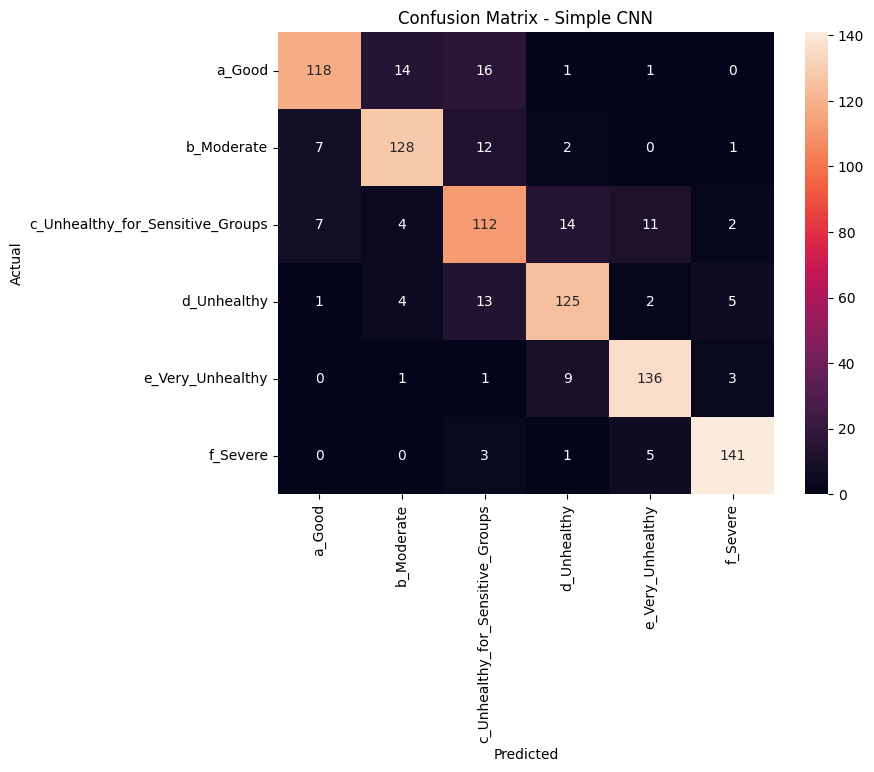

In [61]:
cm = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Simple CNN")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
y_true_resnet, y_pred_resnet = evaluate(resnet, test_loader)

print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))

                                  precision    recall  f1-score   support

                          a_Good       0.60      0.75      0.67       150
                      b_Moderate       0.71      0.53      0.61       150
c_Unhealthy_for_Sensitive_Groups       0.72      0.42      0.53       150
                     d_Unhealthy       0.62      0.83      0.71       150
                e_Very_Unhealthy       0.81      0.82      0.81       150
                        f_Severe       0.85      0.92      0.88       150

                        accuracy                           0.71       900
                       macro avg       0.72      0.71      0.70       900
                    weighted avg       0.72      0.71      0.70       900



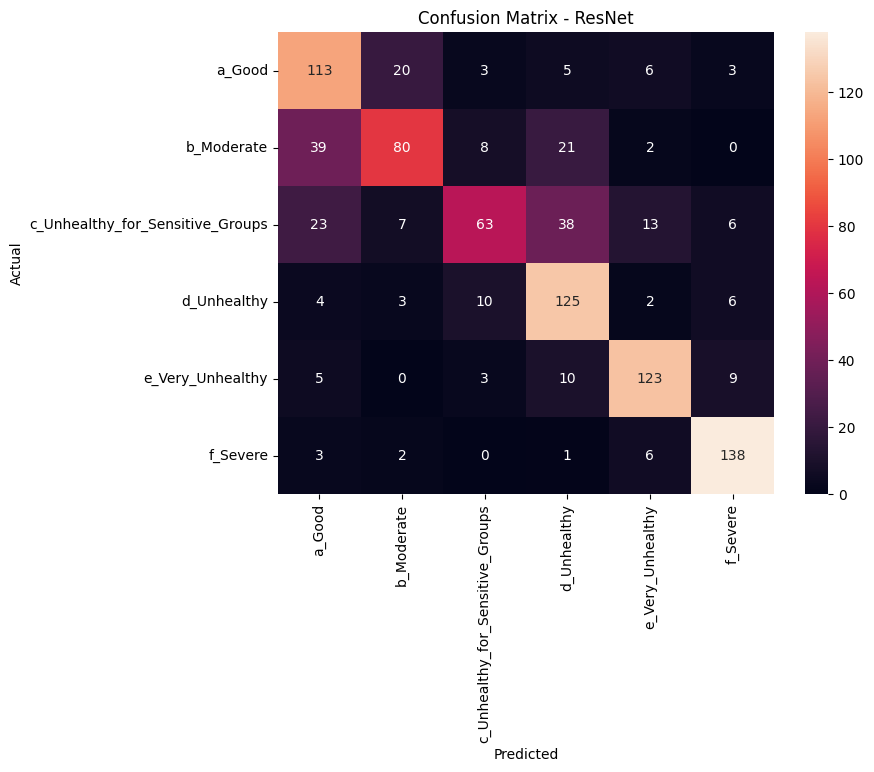

In [63]:
cm = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - ResNet")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Task 5: Training Curves

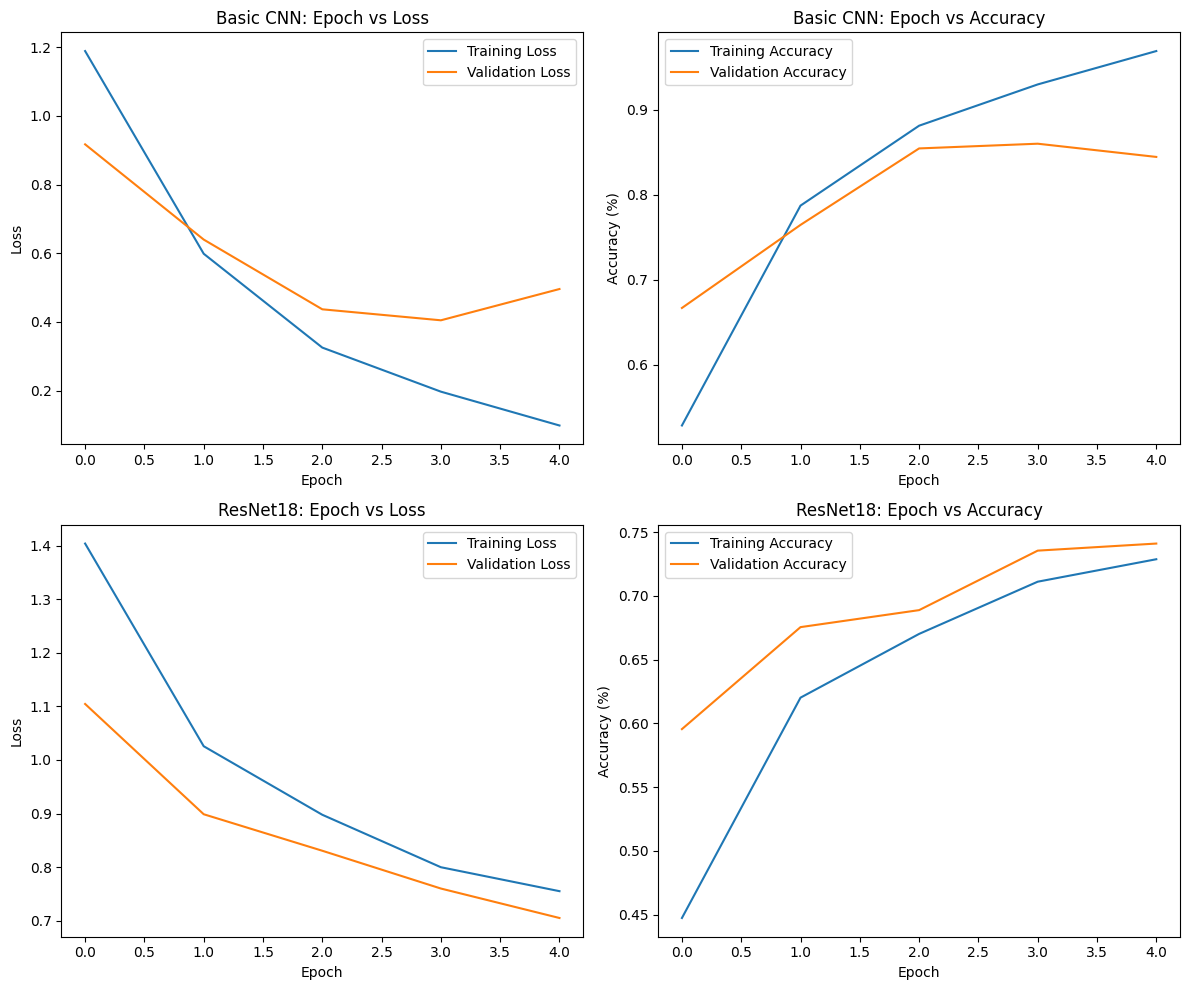

In [69]:
plt.figure(figsize=(12,10))

# ---------------- CNN LOSS ----------------
plt.subplot(2,2,1)

plt.plot(train_loss,label="Training Loss")
plt.plot(val_loss,label="Validation Loss")

plt.title("Basic CNN: Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()


# ---------------- CNN ACCURACY ----------------
plt.subplot(2,2,2)

plt.plot(train_acc,label="Training Accuracy")
plt.plot(val_acc,label="Validation Accuracy")

plt.title("Basic CNN: Epoch vs Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()


# ---------------- RESNET LOSS ----------------
plt.subplot(2,2,3)

plt.plot(train_loss_resnet,label="Training Loss")
plt.plot(val_loss_resnet,label="Validation Loss")

plt.title("ResNet18: Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()


# ---------------- RESNET ACCURACY ----------------
plt.subplot(2,2,4)

plt.plot(train_acc_resnet,label="Training Accuracy")
plt.plot(val_acc_resnet,label="Validation Accuracy")

plt.title("ResNet18: Epoch vs Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()


plt.tight_layout()

plt.show()

#Task 6: Misclassification Analysis

In [66]:
misclassified = []

for i in range(len(y_true_resnet)):

    if y_true_resnet[i] != y_pred_resnet[i]:
        misclassified.append(i)

misclassified = misclassified[:5]

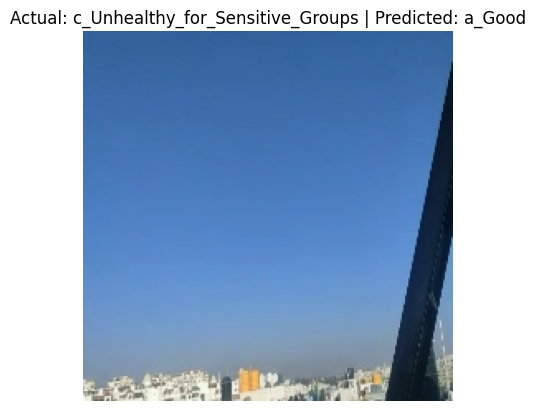

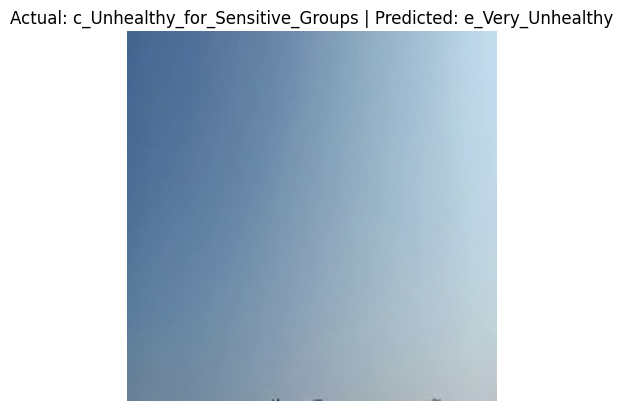

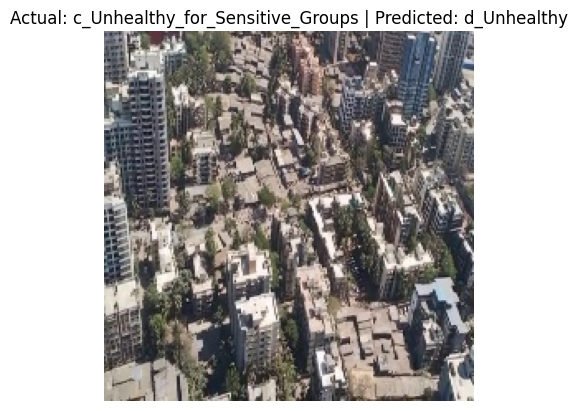

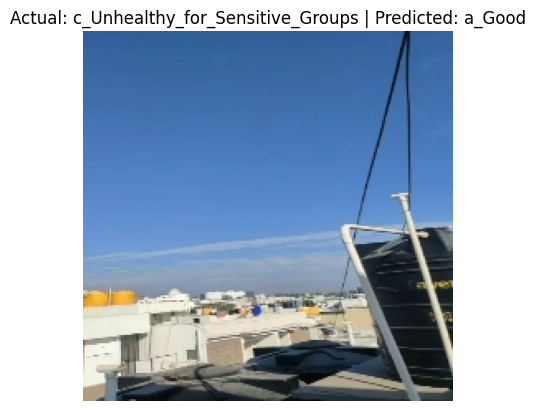

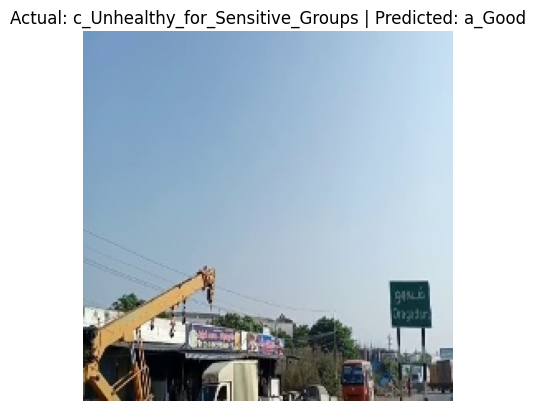

In [67]:
for i in misclassified:

    img_path = os.path.join(image_folder, test_df.iloc[i]['image_path'])

    img = Image.open(img_path)

    plt.imshow(img)

    plt.title(
        "Actual: " + class_names[y_true_resnet[i]] +
        " | Predicted: " + class_names[y_pred_resnet[i]]
    )

    plt.axis("off")

    plt.show()

In [68]:
cnn_acc = (np.array(y_true_cnn) == np.array(y_pred_cnn)).mean()
resnet_acc = (np.array(y_true_resnet) == np.array(y_pred_resnet)).mean()

print("CNN Accuracy:", cnn_acc)
print("ResNet Accuracy:", resnet_acc)

CNN Accuracy: 0.8444444444444444
ResNet Accuracy: 0.7133333333333334
